# Part 1 — Data Audit, EDA & Business Understanding

**Capstone:** D2C Customer Churn Intelligence & Retention API  
**Snapshot date:** 2025-09-30  
**Target:** Customer churned in the 60 days after snapshot (2025-10-01 to 2025-11-29)

---


## 1. Imports & Setup

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

DATA_DIR = "data"
CHARTS_DIR = "charts"
os.makedirs(CHARTS_DIR, exist_ok=True)


## 2. Load All Datasets

In [94]:
DATA_DIR = "data"

required_files = {
    "customers": f"{DATA_DIR}/customers.csv",
    "orders": f"{DATA_DIR}/orders.csv",
    "tickets": f"{DATA_DIR}/support_tickets.csv",
    "web": f"{DATA_DIR}/web_events_snapshot.csv",
    "labels": f"{DATA_DIR}/churn_labels.csv",
    "rfm_snap": f"{DATA_DIR}/rfm_modeling_snapshot.csv",
    "interventions": f"{DATA_DIR}/intervention_history.csv",
}

customers = pd.read_csv(required_files["customers"], parse_dates=["signup_date"])
orders = pd.read_csv(required_files["orders"], parse_dates=["order_date"])
tickets = pd.read_csv(required_files["tickets"], parse_dates=["ticket_date"])
web = pd.read_csv(required_files["web"], parse_dates=["snapshot_date"])
labels = pd.read_csv(required_files["labels"], parse_dates=["snapshot_date"])
rfm_snap = pd.read_csv(required_files["rfm_snap"], parse_dates=["snapshot_date"])
interventions = pd.read_csv(required_files["interventions"], parse_dates=["snapshot_date"])

SNAPSHOT_DATE = pd.Timestamp("2025-09-30")

print("All files loaded.")

for name, df in [
    ("customers", customers),
    ("orders", orders),
    ("tickets", tickets),
    ("web", web),
    ("labels", labels),
    ("rfm_snap", rfm_snap),
    ("interventions", interventions),
]:
    print(f"{name:15s}: {df.shape[0]:,} rows × {df.shape[1]} cols")

All files loaded.
customers      : 2,400 rows × 9 cols
orders         : 10,009 rows × 10 cols
tickets        : 1,921 rows × 8 cols
web            : 2,400 rows × 10 cols
labels         : 2,400 rows × 4 cols
rfm_snap       : 2,400 rows × 29 cols
interventions  : 2,400 rows × 5 cols


## 3. Schema Inspection

In [95]:
for name, df in [("customers", customers), ("orders", orders), ("tickets", tickets),
                 ("web", web), ("labels", labels), ("interventions", interventions)]:
    print(f"\n{'='*50}")
    print(f"  {name.upper()}")
    print(f"{'='*50}")
    print(df.dtypes.to_string())
    print(f"\nFirst 2 rows:")
    display(df.head(2))



  CUSTOMERS
customer_id                    object
signup_date            datetime64[ns]
city_tier                      object
age_group                      object
acquisition_channel            object
loyalty_tier                   object
preferred_category             object
skin_type                      object
marketing_consent              object

First 2 rows:


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes



  ORDERS
order_id                 object
customer_id              object
order_date       datetime64[ns]
category                 object
quantity                  int64
gross_amount            float64
discount_pct            float64
delivery_days             int64
returned                  int64
rating                  float64

First 2 rows:


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.00
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.00



  TICKETS
ticket_id                   object
customer_id                 object
ticket_date         datetime64[ns]
issue_type                  object
support_channel             object
resolution_hours           float64
sentiment_score            float64
reopened                     int64

First 2 rows:


...

,customer_id,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,2025-09-30,1,4,0,0,0,2,0,20
1,CUST00002,2025-09-30,8,31,4,2,3,0,0,0



  LABELS
customer_id               object
snapshot_date     datetime64[ns]
churn_next_60d             int64
split                     object

First 2 rows:


,customer_id,snapshot_date,churn_next_60d,split
0,CUST00001,2025-09-30,1,train
1,CUST00002,2025-09-30,0,train



  INTERVENTIONS
customer_id                       object
snapshot_date             datetime64[ns]
last_campaign_received            object
last_campaign_cost                 int64
manual_priority_bucket            object

First 2 rows:


,customer_id,snapshot_date,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,2025-09-30,welcome_offer,25,high
1,CUST00002,2025-09-30,free_shipping,12,medium


## 4. Build the Master Table

We left-join everything onto `customers` (2,400 rows = universe).  
Support tickets are many-to-one so we aggregate first.


In [96]:
# Aggregate tickets per customer (pre-snapshot only — all tickets are pre-snapshot)
ticket_agg = (
    tickets
    .groupby("customer_id")
    .agg(
        ticket_count=("ticket_id", "count"),
        avg_sentiment=("sentiment_score", "mean"),
        pct_reopened=("reopened", "mean"),
        avg_resolution_hrs=("resolution_hours", "mean"),
    )
    .reset_index()
)

# Pre-snapshot orders only (leakage guard)
orders_pre = orders[orders["order_date"] <= SNAPSHOT_DATE].copy()

# Order-level aggregates per customer
order_agg = (
    orders_pre
    .groupby("customer_id")
    .agg(
        total_orders=("order_id", "count"),
        total_spend=("gross_amount", "sum"),
        avg_order_value=("gross_amount", "mean"),
        return_rate=("returned", "mean"),
        avg_discount=("discount_pct", "mean"),
        avg_rating=("rating", "mean"),
        last_order_date=("order_date", "max"),
        first_order_date=("order_date", "min"),
        n_categories=("category", "nunique"),
    )
    .reset_index()
)
order_agg["recency_days"] = (SNAPSHOT_DATE - order_agg["last_order_date"]).dt.days

# Build master
master = (
    customers
    .merge(labels[["customer_id", "churn_next_60d", "split"]], on="customer_id", how="left")
    .merge(order_agg, on="customer_id", how="left")
    .merge(ticket_agg, on="customer_id", how="left")
    .merge(web, on="customer_id", how="left")
    .merge(interventions[["customer_id", "last_campaign_received",
                           "last_campaign_cost", "manual_priority_bucket"]],
           on="customer_id", how="left")
)

# Customers with zero tickets get 0, not NaN
master["ticket_count"] = master["ticket_count"].fillna(0)

print(f"Master table: {master.shape}")
display(master.head(3))


Master table: (2400, 37)


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent,churn_next_60d,split,total_orders,total_spend,avg_order_value,return_rate,avg_discount,avg_rating,last_order_date,first_order_date,n_categories,recency_days,ticket_count,avg_sentiment,pct_reopened,avg_resolution_hrs,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes,1,train,6,2955.57,492.60,0.17,0.36,3.33,2025-06-15,2024-08-06,3,107,2.00,0.14,0.00,4.35,2025-09-30,1,4,0,0,0,2,0,20,welcome_offer,25,high
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes,0,train,1,581.00,581.00,0.00,0.23,4.00,2025-08-21,2025-08-21,1,40,1.00,0.00,0.00,1.00,2025-09-30,8,31,4,2,3,0,0,0,free_shipping,12,medium
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes,1,train,1,649.98,649.98,0.00,0.47,2.00,2025-04-12,2025-04-12,1,171,0.00,NaN,NaN,NaN,2025-09-30,1,3,0,0,0,0,0,26,none,18,high


## 5. Data Quality Audit

### 5a. Missing values

In [97]:
def missing_summary(df, name):
    total = len(df)
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    if miss.empty:
        print(f"{name}: no missing values")
        return
    result = pd.DataFrame({
        "missing_count": miss,
        "missing_pct": (miss / total * 100).round(2)
    })
    print(f"\n{name}")
    display(result)

for name, df in [("customers", customers), ("orders", orders),
                 ("tickets", tickets), ("web", web)]:
    missing_summary(df, name)



customers


,missing_count,missing_pct
loyalty_tier,1386,57.75
skin_type,401,16.71



orders


,missing_count,missing_pct
rating,80,0.80


tickets: no missing values
web: no missing values


### 5b. Duplicate-like records in orders

In [98]:
# The data dictionary tells us order IDs ending in _DUP are intentional duplicates
dup_orders = orders[orders["order_id"].str.endswith("_DUP")]
print(f"Orders with _DUP suffix: {len(dup_orders)}")

# Also check exact duplicates on meaningful columns
exact_dups = orders.duplicated(subset=["customer_id", "order_date", "category",
                                        "gross_amount"], keep=False)
print(f"Exact content duplicates (excl order_id): {exact_dups.sum()}")

display(dup_orders.head(5))


Orders with _DUP suffix: 12
Exact content duplicates (excl order_id): 24


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
601,ORD008249_DUP,CUST00153,2025-11-04,Hair Care,1,321.31,0.36,8,0,3.00
2621,ORD002124_DUP,CUST00628,2025-03-18,Skin Care,1,410.04,0.47,3,0,5.00
3534,ORD002862_DUP,CUST00837,2025-07-12,Hair Care,3,952.02,0.47,4,0,4.00
3602,ORD002916_DUP,CUST00848,2025-09-26,Skin Care,1,547.18,0.28,2,0,5.00
3675,ORD002970_DUP,CUST00869,2024-12-22,Fragrance,1,818.64,0.18,2,0,4.00


### 5c. Outliers in gross_amount

99th percentile gross_amount: ₹2,309
Orders above 99th pct: 101
Max gross_amount: ₹24,789


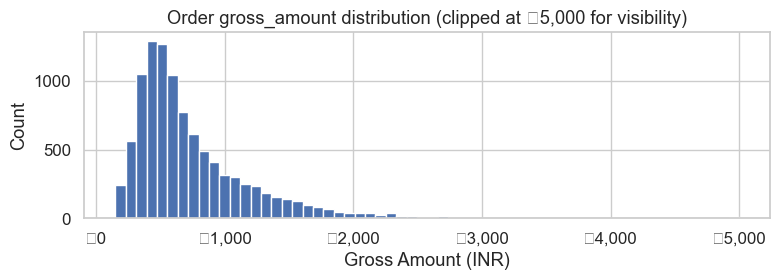

Chart saved: 01_gross_amount_dist.png


In [99]:
q99 = orders["gross_amount"].quantile(0.99)
outliers = orders[orders["gross_amount"] > q99]

print(f"99th percentile gross_amount: ₹{q99:,.0f}")
print(f"Orders above 99th pct: {len(outliers)}")
print(f"Max gross_amount: ₹{orders['gross_amount'].max():,.0f}")

fig, ax = plt.subplots(figsize=(8, 3))
orders["gross_amount"].clip(upper=5000).hist(bins=60, ax=ax, color="#4C72B0", edgecolor="white")
ax.set_title("Distribution of Order Amounts (clipped at ₹5,000 for visibility)")
ax.set_xlabel("Gross Amount (INR)")
ax.set_ylabel("Count")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:,.0f}"))
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/01_gross_amount_dist.png", dpi=130)
plt.show()
print("Chart saved: 01_gross_amount_dist.png")


### 5d. Post-snapshot orders (leakage check)

In [100]:
post_snap = orders[orders["order_date"] > SNAPSHOT_DATE]
pre_snap  = orders[orders["order_date"] <= SNAPSHOT_DATE]

print(f"Total orders   : {len(orders):,}")
print(f"Pre-snapshot   : {len(pre_snap):,}  (safe to use as features)")
print(f"Post-snapshot  : {len(post_snap):,}  (label construction only — NOT for features)")
print(f"\nPost-snapshot date range: {post_snap['order_date'].min().date()} to {post_snap['order_date'].max().date()}")


Total orders   : 10,009
Pre-snapshot   : 8,137  (safe to use as features)
Post-snapshot  : 1,872  (label construction only — NOT for features)

Post-snapshot date range: 2025-10-01 to 2025-11-29


### 5e. Join coverage check

In [101]:
# How many of the 2,400 customers have orders, tickets, etc.?
cust_ids = set(customers["customer_id"])

coverage = {
    "Has orders (pre-snapshot)": orders_pre["customer_id"].nunique(),
    "Has support tickets"      : tickets["customer_id"].nunique(),
    "Has web events"           : web["customer_id"].nunique(),
    "Has churn label"          : labels["customer_id"].nunique(),
    "Has intervention record"  : interventions["customer_id"].nunique(),
}

for k, v in coverage.items():
    print(f"  {k:35s}: {v:,} / 2,400 ({v/24:.1f}%)")


  Has orders (pre-snapshot)          : 2,400 / 2,400 (100.0%)
  Has support tickets                : 1,247 / 2,400 (52.0%)
  Has web events                     : 2,400 / 2,400 (100.0%)
  Has churn label                    : 2,400 / 2,400 (100.0%)
  Has intervention record            : 2,400 / 2,400 (100.0%)


### 5f. Loyalty tier and skin type nulls

In [102]:
print("loyalty_tier null count :", customers["loyalty_tier"].isnull().sum())
print("skin_type null count    :", customers["skin_type"].isnull().sum())

# Null in loyalty_tier means 'not enrolled' — this is meaningful, not random
print("\nloyalty_tier value counts (including NaN):")
print(customers["loyalty_tier"].value_counts(dropna=False))


loyalty_tier null count : 1386
skin_type null count    : 401

loyalty_tier value counts (including NaN):
loyalty_tier
NaN         1386
Silver       590
Gold         319
Platinum     105
Name: count, dtype: int64


## 6. Exploratory Data Analysis

### 6a. Churn distribution and train/val/test split

Overall churn rate: 47.0%

            count  churned  churn_rate
split                                 
test          336      168        0.50
train        1728      812        0.47
validation    336      147        0.44


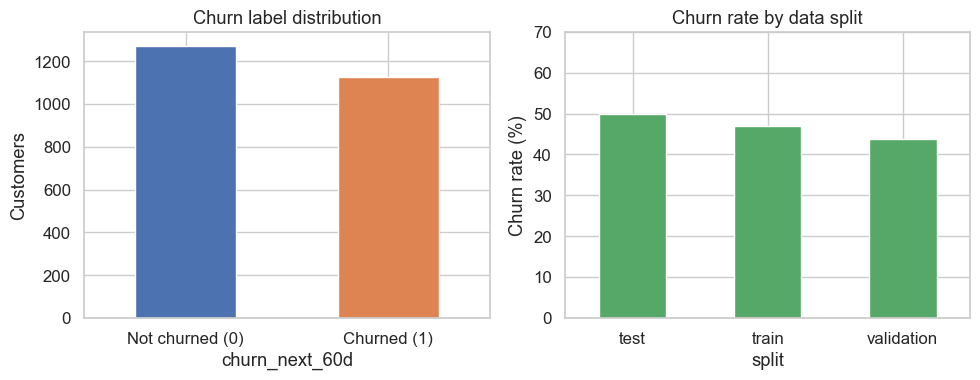

Chart saved: 02_churn_distribution.png


In [103]:
churn_rate = labels["churn_next_60d"].mean()
print(f"Overall churn rate: {churn_rate:.1%}")
print()
print(labels.groupby("split")["churn_next_60d"]
      .agg(count="count", churned="sum", churn_rate="mean")
      .round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

labels["churn_next_60d"].value_counts().plot(
    kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"],
    edgecolor="white", rot=0
)
axes[0].set_title("Churn label distribution")
axes[0].set_xticklabels(["Not churned (0)", "Churned (1)"])
axes[0].set_ylabel("Customers")

(labels.groupby("split")["churn_next_60d"].mean() * 100).plot(
    kind="bar", ax=axes[1], color="#55A868", edgecolor="white", rot=0
)
axes[1].set_title("Churn rate by data split")
axes[1].set_ylabel("Churn rate (%)")
axes[1].set_ylim(0, 70)

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/02_churn_distribution.png", dpi=130)
plt.show()
print("Chart saved: 02_churn_distribution.png")


### 6b. Customer demographics

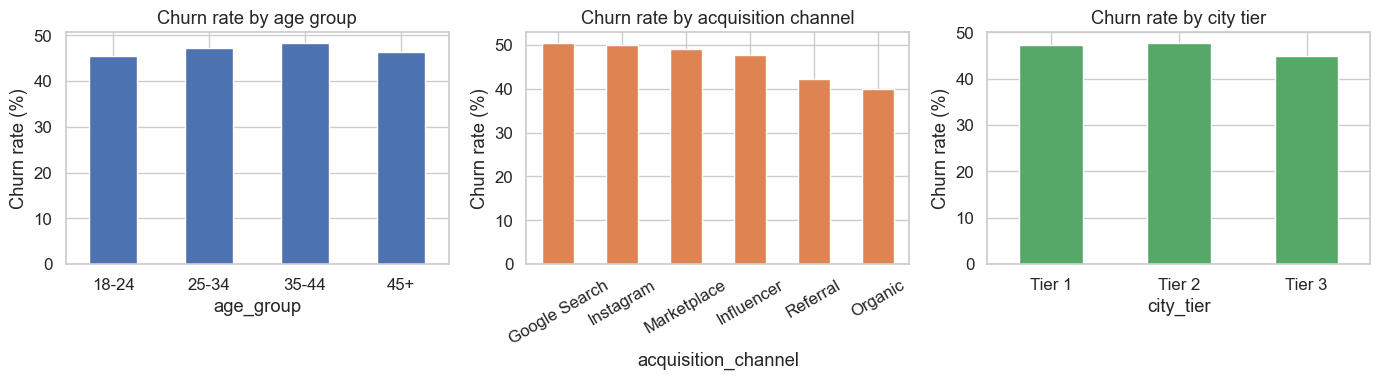

Chart saved: 03_churn_by_demographics.png


In [104]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Age group
cust_churn = customers.merge(labels[["customer_id","churn_next_60d"]], on="customer_id")
cust_churn.groupby("age_group")["churn_next_60d"].mean().mul(100).sort_index().plot(
    kind="bar", ax=axes[0], color="#4C72B0", edgecolor="white", rot=0
)
axes[0].set_title("Churn rate by age group")
axes[0].set_ylabel("Churn rate (%)")

# Acquisition channel
(cust_churn.groupby("acquisition_channel")["churn_next_60d"]
 .mean().mul(100).sort_values(ascending=False)
 .plot(kind="bar", ax=axes[1], color="#DD8452", edgecolor="white", rot=30)
)
axes[1].set_title("Churn rate by acquisition channel")
axes[1].set_ylabel("Churn rate (%)")

# City tier
cust_churn.groupby("city_tier")["churn_next_60d"].mean().mul(100).plot(
    kind="bar", ax=axes[2], color="#55A868", edgecolor="white", rot=0
)
axes[2].set_title("Churn rate by city tier")
axes[2].set_ylabel("Churn rate (%)")

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/03_churn_by_demographics.png", dpi=130)
plt.show()
print("Chart saved: 03_churn_by_demographics.png")


### 6c. Order behaviour vs churn

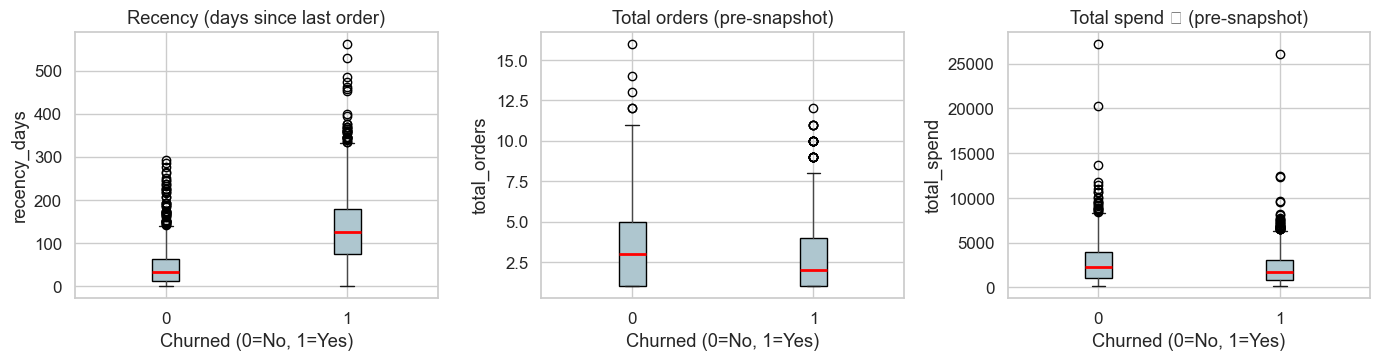

Chart saved: 04_order_behaviour_vs_churn.png


In [105]:
order_churn = order_agg.merge(labels[["customer_id","churn_next_60d"]], on="customer_id")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, title in zip(axes,
    ["recency_days", "total_orders", "total_spend"],
    ["Recency (days since last order)", "Total orders (pre-snapshot)", "Total spend ₹ (pre-snapshot)"]):
    order_churn.boxplot(column=col, by="churn_next_60d", ax=ax,
                        patch_artist=True,
                        boxprops=dict(facecolor="#AEC6CF"),
                        medianprops=dict(color="red", linewidth=2))
    ax.set_title(title)
    ax.set_xlabel("Churned (0=No, 1=Yes)")
    ax.set_ylabel(col)

plt.suptitle("")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/04_order_behaviour_vs_churn.png", dpi=130)
plt.show()
print("Chart saved: 04_order_behaviour_vs_churn.png")


### 6d. Support ticket patterns

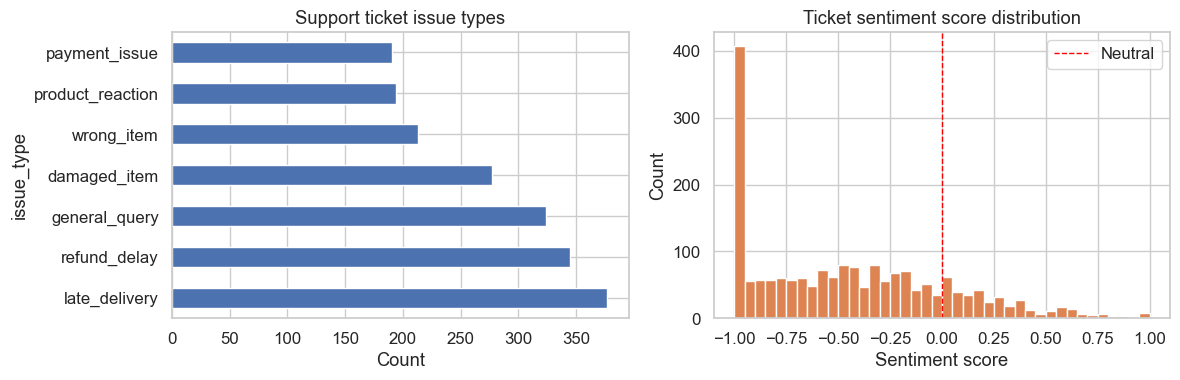

Chart saved: 05_support_ticket_patterns.png

Churn rate by ticket presence:
has_ticket
0   0.47
1   0.47
Name: churn_next_60d, dtype: float64


In [106]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Issue type frequency
tickets["issue_type"].value_counts().plot(
    kind="barh", ax=axes[0], color="#4C72B0", edgecolor="white"
)
axes[0].set_title("Support ticket issue types")
axes[0].set_xlabel("Count")

# Sentiment score distribution
tickets["sentiment_score"].hist(bins=40, ax=axes[1], color="#DD8452", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1, label="Neutral")
axes[1].set_title("Ticket sentiment score distribution")
axes[1].set_xlabel("Sentiment score")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/05_support_ticket_patterns.png", dpi=130)
plt.show()
print("Chart saved: 05_support_ticket_patterns.png")

# Churn rate for customers with/without tickets
has_ticket = ticket_agg["customer_id"].tolist()
labels["has_ticket"] = labels["customer_id"].isin(has_ticket).astype(int)
print("\nChurn rate by ticket presence:")
print(labels.groupby("has_ticket")["churn_next_60d"].mean().round(3))


### 6e. Web/app activity vs churn

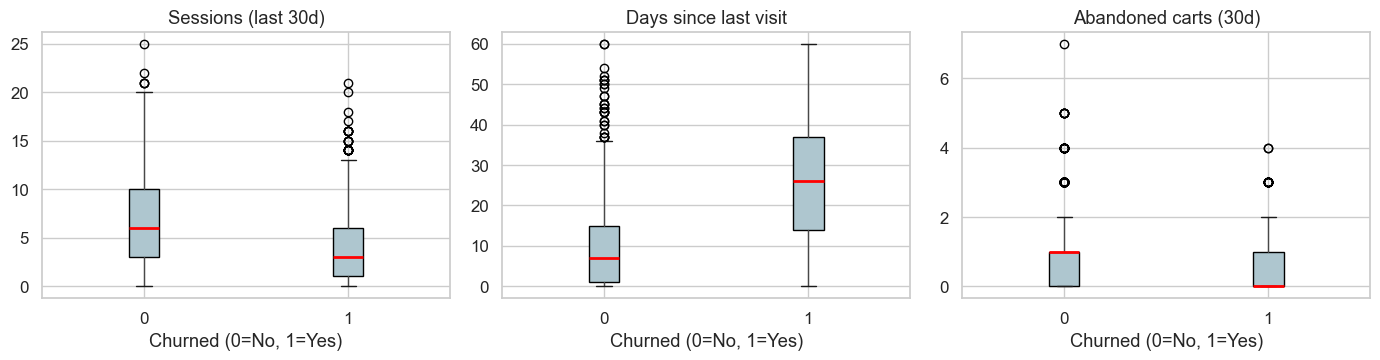

Chart saved: 06_web_activity_vs_churn.png


In [107]:
web_churn = web.merge(labels[["customer_id","churn_next_60d"]], on="customer_id")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, title in zip(axes,
    ["sessions_30d", "last_visit_days_ago", "abandoned_carts_30d"],
    ["Sessions (last 30d)", "Days since last visit", "Abandoned carts (30d)"]):
    web_churn.boxplot(column=col, by="churn_next_60d", ax=ax,
                      patch_artist=True,
                      boxprops=dict(facecolor="#AEC6CF"),
                      medianprops=dict(color="red", linewidth=2))
    ax.set_title(title)
    ax.set_xlabel("Churned (0=No, 1=Yes)")

plt.suptitle("")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/06_web_activity_vs_churn.png", dpi=130)
plt.show()
print("Chart saved: 06_web_activity_vs_churn.png")


### 6f. Loyalty tier vs churn

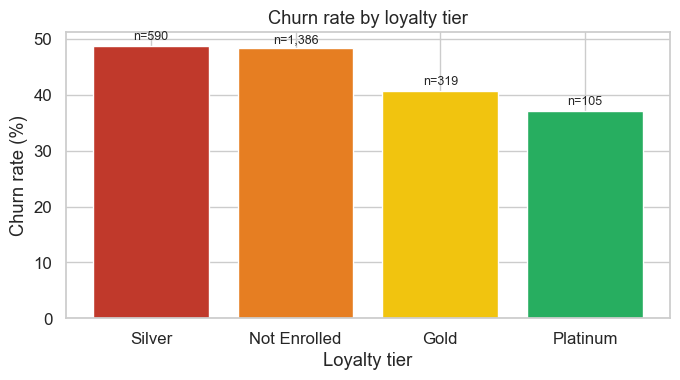

Chart saved: 07_loyalty_vs_churn.png

   loyalty_tier  count  churn_rate
3        Silver    590        0.49
1  Not Enrolled   1386        0.48
0          Gold    319        0.41
2      Platinum    105        0.37

Platinum customers show the lowest churn rate.
Silver and Not Enrolled customers have similar churn rates.
Gold and Platinum tiers show lower churn than the lower tiers.


In [108]:
loyalty_churn = (
    cust_churn.copy()
    .assign(loyalty_tier=lambda df: df["loyalty_tier"].fillna("Not Enrolled"))
    .groupby("loyalty_tier")["churn_next_60d"]
    .agg(count="count", churn_rate="mean")
    .reset_index()
    .sort_values("churn_rate", ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(loyalty_churn["loyalty_tier"],
              loyalty_churn["churn_rate"] * 100,
              color=["#c0392b","#e67e22","#f1c40f","#27ae60"],
              edgecolor="white")
for bar, count in zip(bars, loyalty_churn["count"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"n={count:,}", ha="center", va="bottom", fontsize=9)
ax.set_title("Churn rate by loyalty tier")
ax.set_ylabel("Churn rate (%)")
ax.set_xlabel("Loyalty tier")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/07_loyalty_vs_churn.png", dpi=130)
plt.show()
print("Chart saved: 07_loyalty_vs_churn.png")
print()
print(loyalty_churn)

print()
print("Platinum customers show the lowest churn rate.")
print("Silver and Not Enrolled customers have similar churn rates.")
print("Gold and Platinum tiers show lower churn than the lower tiers.")

### 6g. Discount usage vs churn

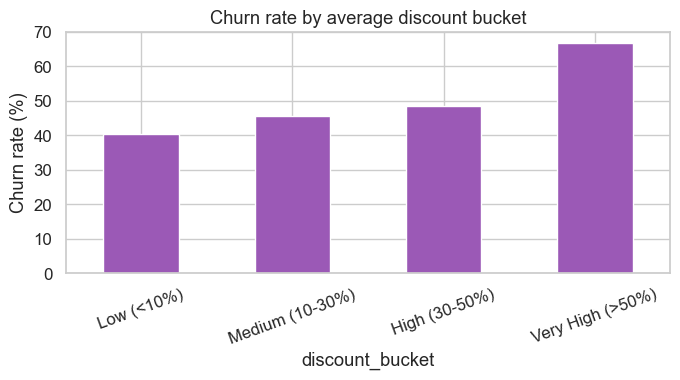

Chart saved: 08_discount_vs_churn.png


In [109]:
disc_churn = order_churn.copy()
disc_churn["discount_bucket"] = pd.cut(disc_churn["avg_discount"],
                                        bins=[0, 0.1, 0.3, 0.5, 1.0],
                                        labels=["Low (<10%)", "Medium (10-30%)",
                                                "High (30-50%)", "Very High (>50%)"])

(disc_churn.groupby("discount_bucket")["churn_next_60d"]
 .mean().mul(100)
 .plot(kind="bar", color="#9B59B6", edgecolor="white", rot=20, figsize=(7, 4))
)
plt.title("Churn rate by average discount bucket")
plt.ylabel("Churn rate (%)")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/08_discount_vs_churn.png", dpi=130)
plt.show()
print("Chart saved: 08_discount_vs_churn.png")


## 7. Churn-Risk Hypotheses

Based on the EDA above, here are five evidence-backed hypotheses.


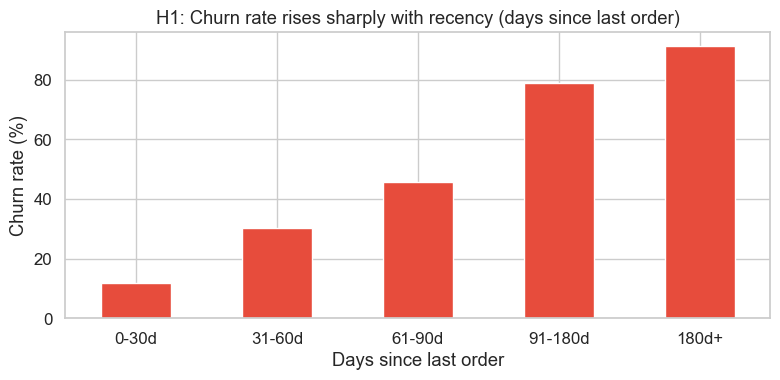

H1 — Churn rate by recency bucket:
recency_days
0-30d     11.90
31-60d    30.40
61-90d    45.70
91-180d   78.70
180d+     91.40
Name: churn_next_60d, dtype: float64


In [110]:
# ── Hypothesis 1: High recency → high churn ──────────────────────────────
recency_bins = pd.cut(order_churn["recency_days"],
                       bins=[0, 30, 60, 90, 180, 999],
                       labels=["0-30d","31-60d","61-90d","91-180d","180d+"])
h1 = order_churn.groupby(recency_bins)["churn_next_60d"].mean().mul(100)

fig, ax = plt.subplots(figsize=(8, 4))
h1.plot(kind="bar", ax=ax, color="#E74C3C", edgecolor="white", rot=0)
ax.set_title("H1: Churn rate rises sharply with recency (days since last order)")
ax.set_ylabel("Churn rate (%)")
ax.set_xlabel("Days since last order")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/H1_recency_vs_churn.png", dpi=130)
plt.show()
print("H1 — Churn rate by recency bucket:")
print(h1.round(1))


In [111]:
# ── Hypothesis 2: Not enrolled in loyalty programme → higher churn ────────
print("H2 — Churn rate by loyalty tier:")
print(loyalty_churn.set_index("loyalty_tier")[["churn_rate","count"]].round(3))
print("\nPlatinum customers show the lowest churn rate.")
print("Silver and Not Enrolled customers have similar churn rates.")
print("Gold and Platinum tiers show lower churn than the lower tiers.")

H2 — Churn rate by loyalty tier:
              churn_rate  count
loyalty_tier                   
Silver              0.49    590
Not Enrolled        0.48   1386
Gold                0.41    319
Platinum            0.37    105

Platinum customers show the lowest churn rate.
Silver and Not Enrolled customers have similar churn rates.
Gold and Platinum tiers show lower churn than the lower tiers.


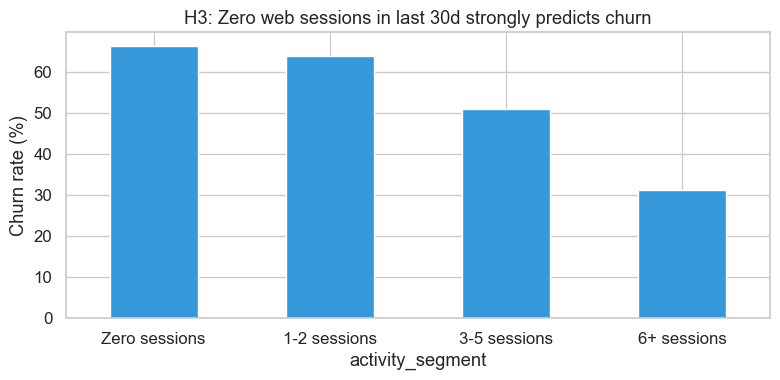

activity_segment
Zero sessions   66.30
1-2 sessions    63.90
3-5 sessions    50.90
6+ sessions     31.20
Name: churn_next_60d, dtype: float64


In [112]:
# ── Hypothesis 3: Low web activity (last 30d) → higher churn ─────────────
h3 = web_churn.copy()
h3["activity_segment"] = pd.cut(h3["sessions_30d"],
                                  bins=[-1, 0, 2, 5, 999],
                                  labels=["Zero sessions","1-2 sessions",
                                          "3-5 sessions","6+ sessions"])
h3_result = h3.groupby("activity_segment")["churn_next_60d"].mean().mul(100)

fig, ax = plt.subplots(figsize=(8, 4))
h3_result.plot(kind="bar", ax=ax, color="#3498DB", edgecolor="white", rot=0)
ax.set_title("H3: Zero web sessions in last 30d strongly predicts churn")
ax.set_ylabel("Churn rate (%)")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/H3_web_sessions_vs_churn.png", dpi=130)
plt.show()
print(h3_result.round(1))


In [113]:
# ── Hypothesis 4: High discount dependency → higher churn ────────────────
print("H4 — Churn rate by discount bucket:")
h4 = disc_churn.groupby("discount_bucket")["churn_next_60d"].mean().mul(100)
print(h4.round(1))
print("\nCustomers who always bought on deep discounts churn more when offers stop.")


H4 — Churn rate by discount bucket:
discount_bucket
Low (<10%)         40.30
Medium (10-30%)    45.60
High (30-50%)      48.60
Very High (>50%)   66.70
Name: churn_next_60d, dtype: float64

Customers who always bought on deep discounts churn more when offers stop.


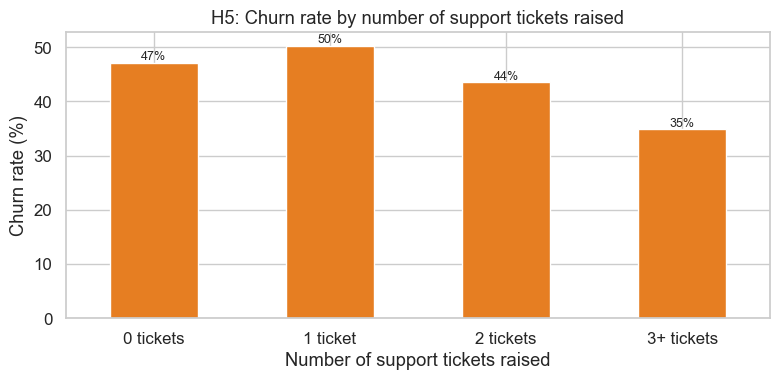

Churn rate by ticket bucket:
ticket_bucket
0 tickets    47.20
1 ticket     50.30
2 tickets    43.60
3+ tickets   34.90
Name: churn_next_60d, dtype: float64


In [ ]:
# H5: Relationship between support tickets and churn
# Use master table so all 2,400 customers are included (including zero-ticket ones)

ticket_churn = master[["customer_id", "ticket_count", "churn_next_60d"]].copy()

ticket_churn["ticket_bucket"] = pd.cut(
    ticket_churn["ticket_count"],
    bins=[-1, 0, 1, 2, 9999],
    labels=["0 tickets", "1 ticket", "2 tickets", "3+ tickets"]
)

h5 = ticket_churn.groupby("ticket_bucket")["churn_next_60d"].mean().mul(100)

fig, ax = plt.subplots(figsize=(8, 4))
h5.plot(kind="bar", ax=ax, color="#E67E22", edgecolor="white", rot=0)
for i, v in enumerate(h5):
    ax.text(i, v + 0.5, f"{v:.0f}%", ha="center", fontsize=9)
ax.set_title("H5: Churn rate by number of support tickets raised")
ax.set_ylabel("Churn rate (%)")
ax.set_xlabel("Number of support tickets raised")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/H5_tickets_vs_churn.png", dpi=130)
plt.show()

print("Churn rate by ticket bucket:")
print(h5.round(1))

## 8. Summary: Key Numbers for the Business Memo

In [115]:
churn_rate    = labels["churn_next_60d"].mean()
no_ticket_pct = 1 - len(ticket_agg) / 2400
loyalty_null  = customers["loyalty_tier"].isnull().mean()
post_snap_rows= len(post_snap)
dup_count     = len(dup_orders)
outlier_count = len(orders[orders["gross_amount"] > orders["gross_amount"].quantile(0.99)])

print("=== Key Numbers ===")
print(f"Overall churn rate          : {churn_rate:.1%}")
print(f"Customers with no tickets   : {no_ticket_pct:.1%}")
print(f"Customers not in loyalty prog: {loyalty_null:.1%}")
print(f"Post-snapshot orders (label only): {post_snap_rows:,}")
print(f"Duplicate-like order records: {dup_count}")
print(f"Gross-amount outliers (>99p) : {outlier_count}")


=== Key Numbers ===
Overall churn rate          : 47.0%
Customers with no tickets   : 48.0%
Customers not in loyalty prog: 57.8%
Post-snapshot orders (label only): 1,872
Duplicate-like order records: 12
Gross-amount outliers (>99p) : 101


---
* The End of Part 1 EDA notebook *